# Ejemplo: Función `get_features_num_regression()`

## Objetivo
Demostrar cómo utilizar la función `get_features_num_regression()` para seleccionar variables numéricas que tienen una **correlación estadísticamente significativa** con una variable target en un problema de **regresión**.

Esta función es útil en la fase de **selección de features** de un proyecto de Machine Learning.

In [2]:
# Importar librerías necesarias
import sys
sys.path.append('/Users/radc/Documents/DS_TheBridge/TEAM_7.-CHALLENGE-TOOLBOX')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Importar la función del módulo toolbox_ML
from toolbox_ML import get_features_num_regression

# Configurar estilo de visualización
plt.style.use('default')
sns.set_palette("husl")

## 1. Cargar el Dataset

Usamos el dataset "tips" de Seaborn, que contiene información sobre propinas en un restaurante.

In [3]:
# Cargar el dataset
df_tips = sns.load_dataset("tips")

# Visualizar las primeras filas
print("Primeras 5 filas del dataset:")
print(df_tips.head())
print("\n" + "="*70 + "\n")

# Ver información del dataset
print("Información del dataset:")
print(df_tips.info())
print("\n" + "="*70 + "\n")

# Estadísticas descriptivas
print("Estadísticas descriptivas:")
print(df_tips.describe())

Primeras 5 filas del dataset:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


Estadísticas descriptivas:
       total_bill         tip        siz

## 2. Análisis Exploratorio

¿Cuál será nuestra variable target?

**Variable Target: `total_bill`** (monto total de la factura)

Nuestro objetivo es encontrar qué variables numéricas están **correlacionadas** con el monto total de la factura.

Matriz de Correlación:
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000




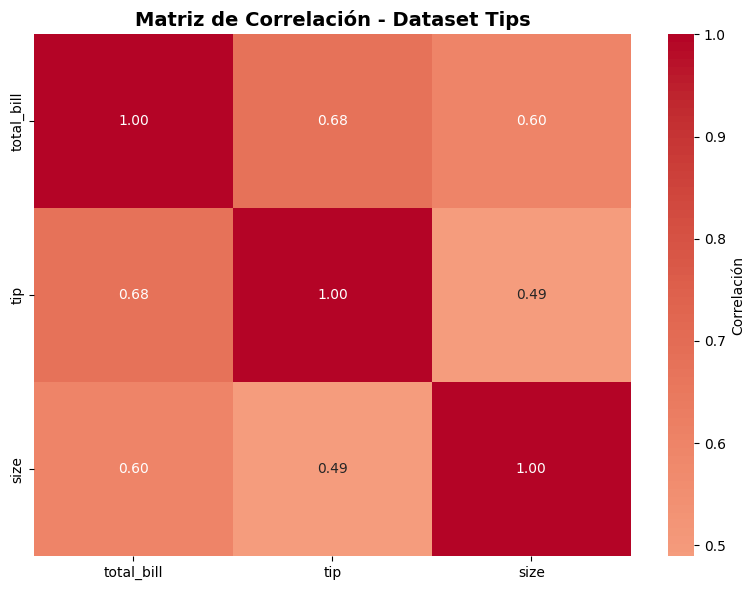

In [4]:
# Visualizamos la correlación entre todas las variables numéricas
print("Matriz de Correlación:")
print(df_tips.corr(numeric_only=True))
print("\n" + "="*70 + "\n")

# Creamos un heatmap de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(df_tips.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, 
            fmt=".2f", cbar_kws={"label": "Correlación"})
plt.title("Matriz de Correlación - Dataset Tips", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Aplicar `get_features_num_regression()`

La función selecciona variables numéricas cuya **correlación absoluta** con el target supere un umbral.

Probamos con diferentes parámetros:

In [5]:
# Caso 1: Sin filtro de p-valor (pvalue_entrada = None)
print("CASO 1: Umbral de correlación = 0.5, sin filtro de p-valor")
print("-" * 70)

features_caso1 = get_features_num_regression(
    df_tips, 
    target_col="total_bill", 
    umbral_corr=0.5,
    pvalue_entrada=None
)

print(f"Features seleccionadas: {features_caso1}")
print("\nInterpretación:")
print("Se seleccionan variables con |correlación| > 0.5")
print("\n" + "="*70 + "\n")

# Caso 2: Con filtro de p-valor más restrictivo
print("CASO 2: Umbral de correlación = 0.3, con p-valor < 0.05")
print("-" * 70)

features_caso2 = get_features_num_regression(
    df_tips, 
    target_col="total_bill", 
    umbral_corr=0.3,
    pvalue_entrada=0.05
)

print(f"Features seleccionadas: {features_caso2}")
print("\nInterpretación:")
print("Se seleccionan variables con |correlación| > 0.3 AND p-valor < 0.05")
print("(Correlación estadísticamente significativa)")
print("\n" + "="*70 + "\n")

# Caso 3: Umbral más bajo
print("CASO 3: Umbral de correlación = 0.2, sin filtro de p-valor")
print("-" * 70)

features_caso3 = get_features_num_regression(
    df_tips, 
    target_col="total_bill", 
    umbral_corr=0.2,
    pvalue_entrada=None
)

print(f"Features seleccionadas: {features_caso3}")
print("\nInterpretación:")
print("Se seleccionan variables con |correlación| > 0.2")
print("(Criterio menos restrictivo)")
print("\n" + "="*70 + "\n")


CASO 1: Umbral de correlación = 0.5, sin filtro de p-valor
----------------------------------------------------------------------
Features seleccionadas: ['tip', 'size']

Interpretación:
Se seleccionan variables con |correlación| > 0.5


CASO 2: Umbral de correlación = 0.3, con p-valor < 0.05
----------------------------------------------------------------------
Features seleccionadas: ['tip', 'size']

Interpretación:
Se seleccionan variables con |correlación| > 0.3 AND p-valor < 0.05
(Correlación estadísticamente significativa)


CASO 3: Umbral de correlación = 0.2, sin filtro de p-valor
----------------------------------------------------------------------
Features seleccionadas: ['tip', 'size']

Interpretación:
Se seleccionan variables con |correlación| > 0.2
(Criterio menos restrictivo)


